<div style="font-family: system-ui, -apple-system, sans-serif; text-align: center; padding: 48px 24px 24px;">
    <div style="display: inline-block; background: #be0f05; color: white;
                padding: 12px 20px; border-radius: 12px; margin-bottom: 20px;">
        <span style="font-size: 34px; font-weight: 800; letter-spacing: -0.5px;">TIP4PATLIBS &ndash; Building the dataset &mdash; the search strategy</span>
    </div>
    <div style="font-size: 16px; color: #475569; margin-bottom: 8px; line-height: 1.6;">
        How a precise corpus of <strong>antibiotic-resistance patent families</strong> is defined: keywords AND classifications, and why the obvious acronyms are deliberately left out.
    </div>
    <div style="font-size: 13px; color: #94a3b8; margin-bottom: 32px;">
        EPO Academy Training Material &nbsp;&middot;&nbsp; landscape analyses after <span style="color: #be0f05; font-weight: 600;">Riccardo Priore</span>, Centro PATLIB, AREA Science Park
    </div>
    <div style="background: #f8fafc; border-radius: 12px; padding: 24px 28px; max-width: 680px;
                margin: 0 auto; border: 1px solid #e2e8f0; text-align: left;">
        <div style="font-size: 14px; color: #334155; line-height: 1.9;">
            <strong>What this notebook does</strong>
            <br/>Step&nbsp;1 &nbsp;&middot;&nbsp; Connect to PATSTAT<br/>Step&nbsp;2 &nbsp;&middot;&nbsp; Keyword strategy &mdash; and what we exclude<br/>Step&nbsp;3 &nbsp;&middot;&nbsp; IPC / CPC classification filters<br/>Step&nbsp;4 &nbsp;&middot;&nbsp; Combine: keywords AND (IPC OR CPC)<br/>Step&nbsp;5 &nbsp;&middot;&nbsp; One representative publication per family<br/>Step&nbsp;6 &nbsp;&middot;&nbsp; Export the dataset the other notebooks build on<br/>Step&nbsp;7&ndash;8 &nbsp;&middot;&nbsp; A first look: growth over time &amp; technology mix
        </div>
    </div>
    <div style="background: #fdf2f2; border-radius: 10px; padding: 16px 24px; max-width: 680px;
                margin: 28px auto 0; border: 1px solid #fecaca;">
        <div style="font-size: 14px; color: #404955; font-weight: 600;">&#9654; &nbsp;Part 1 of 4 &mdash; run the four notebooks of this module in order.</div>
        <div style="font-size: 12px; color: #64748b; margin-top: 6px; line-height: 1.6;">
            Re-running needs <strong>EPO&nbsp;TIP</strong> (it queries PATSTAT&nbsp;PROD via <code>epo.tipdata</code>).
            Each notebook writes what the next one reads; notebook&nbsp;4 assembles the report.
        </div>
    </div>
    <div style="margin-top: 20px; font-size: 12px; color: #cbd5e1;">
        Part of EPO TIP Working Group Sessions, 2026. &nbsp;Data: EPO PATSTAT Global.
    </div>
</div>

## Step 1 — Connect to PATSTAT

We open a PATSTAT **PROD** session and use the ORM (SQLAlchemy) query interface. We also import `report_kit`, the tiny helper that saves each chart as an inline fragment plus the data behind it, so notebook 4 can assemble everything later. All outputs of this notebook land in `1_dataset_and_search_strategy_output/`.

In [9]:
import pandas as pd
import numpy as np
from sqlalchemy import or_

from epo.tipdata.patstat import PatstatClient
from epo.tipdata.patstat.database.models import (
    TLS201_APPLN, TLS202_APPLN_TITLE, TLS203_APPLN_ABSTR,
    TLS209_APPLN_IPC, TLS211_PAT_PUBLN, TLS224_APPLN_CPC,
)

import report_kit  # the per-analysis save contract (fragment + data + manifest)

patstat = PatstatClient(env='PROD')
db = patstat.orm()

OUT = "1_dataset_and_search_strategy_output"
import os; os.makedirs(OUT, exist_ok=True)
print("PATSTAT PROD session ready.")

PATSTAT PROD session ready.


## Step 2 — The keyword strategy (and what we deliberately exclude)

The corpus targets **bacterial antibiotic resistance** specifically. We search titles and abstracts for three groups of terms — the core concept, the resistance *mechanisms*, and an explicit bacterial context. We deliberately **exclude** generic "drug resistance" (which is dominated by cancer), and we avoid bare acronyms (MRSA, VRE, ESBL) because they are noisy. Precision comes from requiring a classification match as well (Step 4).

In [10]:
# Group 1 — core antibiotic-resistance terms
keywords_core = [
    "%antibiotic resistance%", "%antibiotic resistant%",
    "%antimicrobial resistance%", "%antimicrobial resistant%",
    "%antibacterial resistance%", "%antibacterial resistant%",
    "%β-lactam resistance%", "%beta-lactam resistance%", "%beta lactam resistance%",
]
# Group 2 — bacterial resistance mechanisms
keywords_mechanisms = [
    "%beta-lactamase%", "%β-lactamase%", "%carbapenemase%", "%penicillinase%",
    "%cephalosporinase%", "%methicillin resistance%", "%vancomycin resistance%",
    "%carbapenem resistance%", "%colistin resistance%", "%polymyxin resistance%",
]
# Group 3 — explicit bacterial context
keywords_bacterial = [
    "%multidrug-resistant bacteria%", "%antibiotic-resistant bacteria%",
    "%drug-resistant bacteria%", "%bacterial antibiotic resistance%",
    "%bacterial drug resistance%", "%antimicrobial susceptibility%bacteria%",
    "%antibiotic susceptibility%bacteria%",
]

all_keywords = keywords_core + keywords_mechanisms + keywords_bacterial
print(f"{len(all_keywords)} keyword patterns "
      f"({len(keywords_core)} core, {len(keywords_mechanisms)} mechanisms, {len(keywords_bacterial)} bacterial)")
print("Excluded on purpose: generic 'drug resistance' (cancer), bare acronyms (MRSA, VRE, ESBL).")

26 keyword patterns (9 core, 10 mechanisms, 7 bacterial)
Excluded on purpose: generic 'drug resistance' (cancer), bare acronyms (MRSA, VRE, ESBL).


## Step 3 — Classification filters (IPC / CPC), with exact spacing

Keywords alone are noisy, so a family must *also* carry a relevant classification. **Watch the spacing**: an 8-character IPC symbol is a 4-character subclass, padding spaces, then the main-group number — e.g. `A61K  31` (two spaces) or `C12Q   1` (three spaces). The same code list serves as both IPC and CPC filter.

In [11]:
# 1. Pharmaceutical preparations (A61K)
ipc_pharma = ["A61K", "A61K  31", "A61K  38", "A61K  39"]
# 2. Therapeutic activity (A61P) — A61P  31 = antiinfectives, the key one
ipc_therapeutic = ["A61P", "A61P  31"]
# 3. Diagnostics & testing (C12Q, G01N)
ipc_diagnostics = ["C12Q", "C12Q   1", "G01N", "G01N  33"]
# 4. Microorganisms (C12N, C12P)
ipc_micro = ["C12N", "C12N   1", "C12N  15", "C12P"]
# 5. Chemistry of antibiotics (C07D, C07K)
ipc_chemistry = ["C07D", "C07K", "C07K   7"]
# 6. Biocides / antimicrobials (A01N)
ipc_biocides = ["A01N", "A01N  43"]

ipc_codes_all = (ipc_pharma + ipc_therapeutic + ipc_diagnostics
                 + ipc_micro + ipc_chemistry + ipc_biocides)
cpc_codes_all = ipc_codes_all.copy()   # CPC uses the same symbols
print(f"{len(ipc_codes_all)} IPC/CPC classification filters.")

19 IPC/CPC classification filters.


## Step 4 — Combine: keywords AND (IPC OR CPC)

The precise corpus is the **intersection** of two sets of `docdb_family_id`s: families that match a keyword, AND families that match a classification (IPC or CPC). We find each set separately, then intersect.

In [12]:
# families matching a keyword in title OR abstract
fam_kw = (db.query(TLS201_APPLN.docdb_family_id)
    .join(TLS203_APPLN_ABSTR, TLS203_APPLN_ABSTR.appln_id == TLS201_APPLN.appln_id)
    .join(TLS202_APPLN_TITLE, TLS202_APPLN_TITLE.appln_id == TLS201_APPLN.appln_id)
    .filter(or_(
        or_(*[TLS203_APPLN_ABSTR.appln_abstract.like(k) for k in all_keywords]),
        or_(*[TLS202_APPLN_TITLE.appln_title.like(k) for k in all_keywords]),
    )).distinct().all())
fam_kw = {r.docdb_family_id for r in fam_kw}

# families matching an IPC classification
fam_ipc = (db.query(TLS201_APPLN.docdb_family_id)
    .join(TLS209_APPLN_IPC, TLS201_APPLN.appln_id == TLS209_APPLN_IPC.appln_id)
    .filter(or_(*[TLS209_APPLN_IPC.ipc_class_symbol.like(c + '%') for c in ipc_codes_all]))
    .distinct().all())
fam_ipc = {r.docdb_family_id for r in fam_ipc}

# families matching a CPC classification
fam_cpc = (db.query(TLS201_APPLN.docdb_family_id)
    .join(TLS224_APPLN_CPC, TLS201_APPLN.appln_id == TLS224_APPLN_CPC.appln_id)
    .filter(or_(*[TLS224_APPLN_CPC.cpc_class_symbol.like(c + '%') for c in cpc_codes_all]))
    .distinct().all())
fam_cpc = {r.docdb_family_id for r in fam_cpc}

final_families = list(fam_kw & (fam_ipc | fam_cpc))
print(f"keywords: {len(fam_kw):,} | classifications (IPC|CPC): {len(fam_ipc | fam_cpc):,}")
print(f"FINAL (keywords AND classification): {len(final_families):,} families")

keywords: 5,657 | classifications (IPC|CPC): 5,486,926
FINAL (keywords AND classification): 4,997 families


## Step 5 — One representative publication per family (EP > WO > US)

We restrict to filings from **2000 onwards**, pull English titles and abstracts, then pick **one** representative publication per family, preferring EP, then WO, then US (else the first available). That gives one clean row per family with a citable publication number.

In [13]:
rows = (db.query(
        TLS201_APPLN.docdb_family_id, TLS201_APPLN.earliest_filing_year,
        TLS202_APPLN_TITLE.appln_title, TLS203_APPLN_ABSTR.appln_abstract)
    .outerjoin(TLS202_APPLN_TITLE, TLS201_APPLN.appln_id == TLS202_APPLN_TITLE.appln_id)
    .outerjoin(TLS203_APPLN_ABSTR, TLS201_APPLN.appln_id == TLS203_APPLN_ABSTR.appln_id)
    .filter(TLS201_APPLN.docdb_family_id.in_(final_families))
    .filter(TLS201_APPLN.earliest_filing_year >= 2000)
    .filter(TLS202_APPLN_TITLE.appln_title_lg == 'en').all())
df = pd.DataFrame(rows, columns=['family', 'year', 'title', 'abstract'])
unique_families = list({int(f) for f in df['family']})
print(f"{len(df):,} records, {len(unique_families):,} unique families, years {int(df['year'].min())}–{int(df['year'].max())}")

pubs = pd.DataFrame(
    db.query(TLS201_APPLN.docdb_family_id, TLS211_PAT_PUBLN.publn_auth, TLS211_PAT_PUBLN.publn_nr)
      .join(TLS211_PAT_PUBLN, TLS201_APPLN.appln_id == TLS211_PAT_PUBLN.appln_id)
      .filter(TLS201_APPLN.docdb_family_id.in_(unique_families)).all(),
    columns=['docdb_family_id', 'publn_auth', 'publn_nr'])

# One representative publication per family, preferring EP > WO > US (else the
# first row). Done by ranking the authority and keeping the top row per family —
# vectorised, and without groupby.apply, whose grouping-column handling pandas
# is changing. A stable sort keeps the original within-family order for ties.
priority = {'EP': 0, 'WO': 1, 'US': 2}
pubs['_rank'] = pubs['publn_auth'].map(priority).fillna(3).astype(int)
rep = (pubs.sort_values('_rank', kind='stable')
           .drop_duplicates('docdb_family_id', keep='first')
           .drop(columns='_rank')
           .reset_index(drop=True))
rep['publication_number'] = rep['publn_auth'] + rep['publn_nr']
final_df = rep[['docdb_family_id', 'publication_number']].copy()
print(f"{len(final_df):,} representative publications selected.")

9,536 records, 4,172 unique families, years 2000–2025
4,172 representative publications selected.


## Step 6 — Export the dataset the other notebooks build on

This `dataset.xlsx` is the **single shared corpus**: notebooks 2 and 3 read it, take the `docdb_family_id` column, and re-query PATSTAT for their own detail.

In [14]:
dataset_path = f"{OUT}/dataset.xlsx"
final_df.to_excel(dataset_path, index=False)
print(f"Wrote {dataset_path} — {len(final_df):,} families.")

Wrote 1_dataset_and_search_strategy_output/dataset.xlsx — 4,172 families.


## Step 7 — A first look: how the field has grown

Our first chart. One year per family (its earliest filing year), counted per year — the growth curve of antibiotic-resistance patenting. `report_kit.record` shows it inline and saves both the figure and the data behind it for the final report.

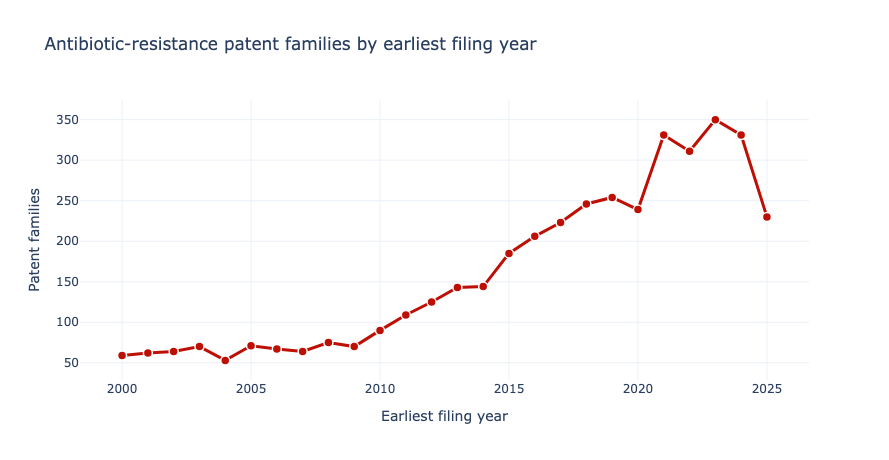

In [15]:
import plotly.graph_objects as go

per_family_year = df.drop_duplicates(subset='family')[['family', 'year']]
by_year = (per_family_year.groupby('year').size()
           .reset_index(name='families').sort_values('year'))

fig = go.Figure(go.Scatter(
    x=by_year['year'], y=by_year['families'], mode='lines+markers',
    line=dict(color='#be0f05', width=3),
    marker=dict(size=9, color='#be0f05', line=dict(color='white', width=1.5))))
fig.update_layout(
    title='Antibiotic-resistance patent families by earliest filing year',
    xaxis_title='Earliest filing year', yaxis_title='Patent families',
    template='plotly_white', height=460)

report_kit.record(110, "families_over_time",
                  "Patent families over time", fig, by_year, output_dir=OUT,
                  note="One representative year (earliest filing) per family, 2000 onwards.")

## Step 8 — Technology composition: the leading IPC classes

Second chart. We pull the IPC classifications for our families, keep the 4-character **class** level (e.g. `A61K`), and show the twenty most frequent — a quick map of which technology areas dominate the corpus.

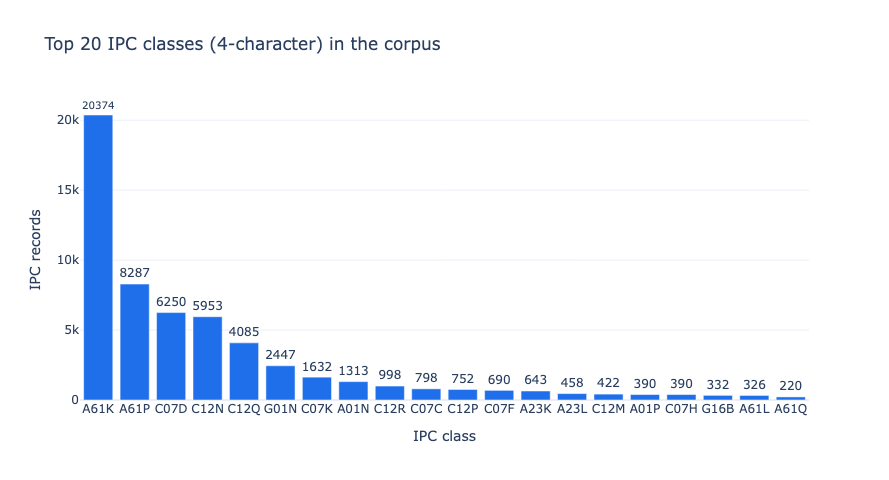

In [16]:
ipc = pd.DataFrame(
    db.query(TLS201_APPLN.docdb_family_id, TLS209_APPLN_IPC.ipc_class_symbol)
      .join(TLS209_APPLN_IPC, TLS201_APPLN.appln_id == TLS209_APPLN_IPC.appln_id)
      .filter(TLS201_APPLN.docdb_family_id.in_(unique_families)).all(),
    columns=['docdb_family_id', 'ipc_class_symbol'])
ipc['ipc_class'] = ipc['ipc_class_symbol'].str[:4]
top = (ipc['ipc_class'].value_counts().head(20)
       .rename_axis('ipc_class').reset_index(name='count'))

fig = go.Figure(go.Bar(
    x=top['ipc_class'], y=top['count'], marker_color='#1f6feb',
    text=top['count'], textposition='outside'))
fig.update_layout(
    title='Top 20 IPC classes (4-character) in the corpus',
    xaxis_title='IPC class', yaxis_title='IPC records', template='plotly_white', height=480)

report_kit.record(120, "top_ipc_classes",
                  "Leading technology areas (IPC classes)", fig, top, output_dir=OUT,
                  note="Count of IPC records at 4-character class level; a family carries several.")

---
**Done.** The corpus is in `1_dataset_and_search_strategy_output/dataset.xlsx`, and two chart contributions are recorded. Continue with notebook 2.